# QAM synchronous digital transmission — Python equivalent of `dt_digital_transmission.m`

This notebook reproduces the processing chain implemented by the MATLAB files in the supplied `QAMSynchronous.zip`:

**random bits → QAM symbol mapping → root-raised-cosine pulse shaping → passband modulation → channel filter + AWGN → Hilbert analytic signal → downconversion → matched filtering → symbol decisions → BER**

The MATLAB main script is:

```matlab
dt_setGlobalConstants
temp=rand(Nbits,1);
txBitStream=temp>0.5;
s=ak_transmitter(txBitStream);
if useIdealChannel==1
    r=s;
else
    r=dt_channel(s);
end
rxBitStream=ak_receiver(r);
BER=ak_estimateBERFromBits(txBitStream, rxBitStream)
```

The notebook uses NumPy/SciPy/Matplotlib and keeps the MATLAB parameters as closely as practical. The original ZIP does not contain the source for some helper functions (`ak_qamSquareConstellation`, `ak_rcosine`, `ak_qamdemod`, `ak_sliceBitStream`, etc.), so those are implemented here explicitly. For `M=32`, the notebook uses a conventional **rectangular 8×4 32-QAM** constellation with nearest-neighbour decisions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import lfilter, fftconvolve, freqz, group_delay

np.set_printoptions(precision=5, suppress=True)
plt.rcParams["figure.figsize"] = (10, 5)

# -------------------------------------------------------------------------
# MATLAB dt_setGlobalConstants.m
# -------------------------------------------------------------------------
Fs = 44_100                 # sampling frequency [Hz]
S = 1_000                   # number of transmitted symbols
L = 80                      # oversampling factor
M = 32                      # number of QAM symbols
useQAM = True
wc = np.pi / 2              # carrier rad/sample = Fs/4

b = int(np.log2(M))         # bits/symbol
Nbits = b * S

useIdealChannel = False
SNRdB = 10.0
phaseCorrection = np.pi / 23

print(f"Fs       = {Fs} Hz")
print(f"S        = {S} symbols")
print(f"L        = {L} samples/symbol")
print(f"M        = {M}-QAM")
print(f"bits/sym = {b}")
print(f"Nbits    = {Nbits}")
print(f"baud     = {Fs/L:.2f} baud")
print(f"bit rate = {(Fs/L)*b:.2f} bit/s")


Fs       = 44100 Hz
S        = 1000 symbols
L        = 80 samples/symbol
M        = 32-QAM
bits/sym = 5
Nbits    = 5000
baud     = 551.25 baud
bit rate = 2756.25 bit/s


## 1. QAM constellation and bit/symbol conversion

The original project calls `ak_qamSquareConstellation(32)`, but that helper is not included in the ZIP. A 32-QAM constellation cannot be a mathematically square \(\sqrt{32}\times\sqrt{32}\) grid, so this implementation uses the common **8×4 rectangular 32-QAM** arrangement.

The mapper interprets every 5-bit word as an integer from 0 to 31 and maps it to one constellation point. The demodulator uses minimum Euclidean distance, which is the equivalent of hard-decision nearest-neighbour detection.

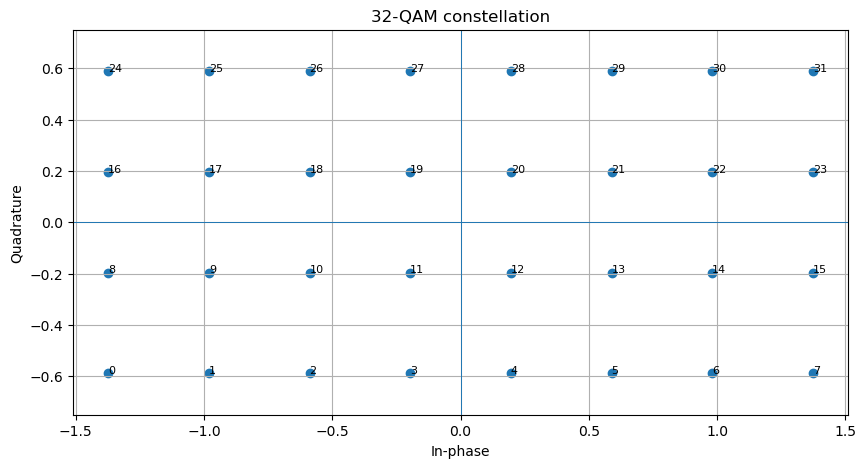

In [2]:
def make_32qam_constellation():
    # 8 levels on I and 4 levels on Q -> 32 points.
    # Levels are odd integers, centred at zero.
    i_levels = np.arange(-7, 8, 2)       # -7,-5,...,7  (8 levels)
    q_levels = np.arange(-3, 4, 2)       # -3,-1,1,3    (4 levels)

    points = []
    for q in q_levels:
        for i in i_levels:
            points.append(i + 1j*q)

    const = np.asarray(points, dtype=np.complex128)

    # Unit-average-power normalization.
    const /= np.sqrt(np.mean(np.abs(const)**2))
    return const


const = make_32qam_constellation()

def bits_to_indices(bits, bits_per_symbol):
    bits = np.asarray(bits, dtype=np.uint8).ravel()
    n = len(bits) // bits_per_symbol
    bits = bits[:n * bits_per_symbol].reshape(n, bits_per_symbol)
    weights = 2 ** np.arange(bits_per_symbol - 1, -1, -1)
    return bits @ weights

def indices_to_bits(indices, bits_per_symbol):
    indices = np.asarray(indices, dtype=np.uint64).ravel()
    shifts = np.arange(bits_per_symbol - 1, -1, -1, dtype=np.uint64)
    return ((indices[:, None] >> shifts) & 1).astype(np.uint8).ravel()

def qam_demod(y, constellation):
    y = np.asarray(y).ravel()
    # Nearest constellation point.
    distances = np.abs(y[:, None] - constellation[None, :])**2
    return np.argmin(distances, axis=1)

plt.figure()
plt.scatter(const.real, const.imag)
for k, z in enumerate(const):
    plt.annotate(str(k), (z.real, z.imag), fontsize=8)
plt.axhline(0, lw=0.7)
plt.axvline(0, lw=0.7)
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.title("32-QAM constellation")
plt.grid(True)
plt.axis("equal")
plt.show()


## 2. Transmit and receive root-raised-cosine filters

MATLAB uses:

```matlab
htx=ak_rcosine(1,L,'fir/sqrt',1,10);
hrx=conj(fliplr(htx));
```

The code below constructs a square-root raised-cosine FIR pulse with roll-off \(\alpha=1\), 10-symbol span, and 80 samples/symbol. The receiver uses the time-reversed conjugate as the matched filter.

Because the implementation of `ak_rcosine` is not included in the ZIP, tiny numerical differences from MATLAB's original custom helper are expected.

Number of Tx taps: 801
Tx filter energy: 1.0
Rx filter energy: 1.0


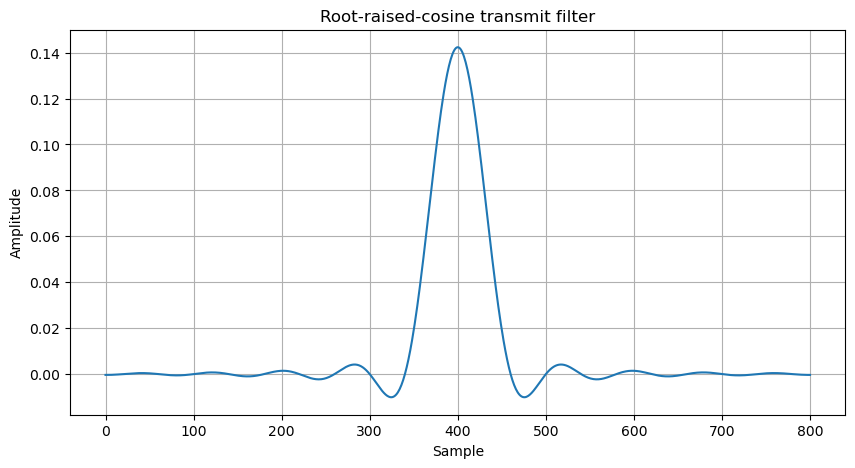

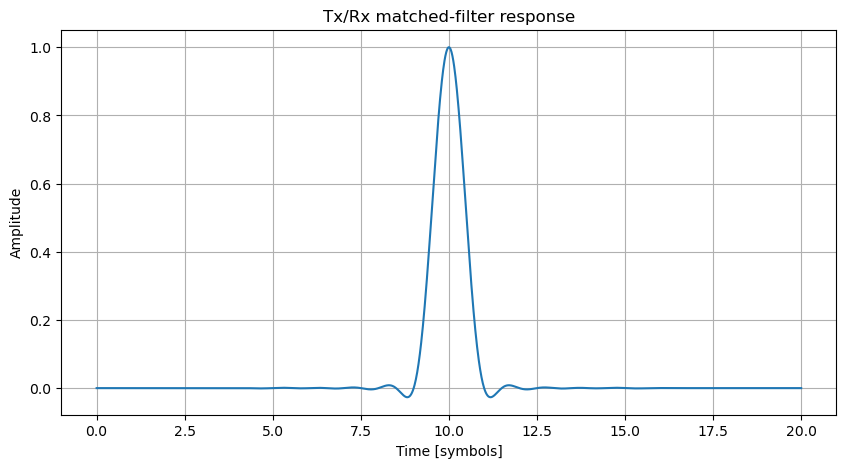

In [3]:
def root_raised_cosine(alpha=1.0, sps=80, span_symbols=10):
    # span_symbols is the total filter duration in symbols.
    # Use span*sps + 1 symmetric taps.
    N = span_symbols * sps
    t = np.arange(-N/2, N/2 + 1) / sps

    h = np.zeros_like(t, dtype=float)

    for k, tk in enumerate(t):
        if np.isclose(tk, 0.0):
            h[k] = 1 - alpha + 4*alpha/np.pi
        elif alpha > 0 and np.isclose(abs(tk), 1/(4*alpha)):
            h[k] = (alpha/np.sqrt(2)) * (
                (1 + 2/np.pi) * np.sin(np.pi/(4*alpha)) +
                (1 - 2/np.pi) * np.cos(np.pi/(4*alpha))
            )
        else:
            numerator = (
                np.sin(np.pi*tk*(1-alpha)) +
                4*alpha*tk*np.cos(np.pi*tk*(1+alpha))
            )
            denominator = np.pi*tk*(1 - (4*alpha*tk)**2)
            h[k] = numerator / denominator

    # Normalize so that the discrete-time filter has unit energy.
    h /= np.sqrt(np.sum(h**2))
    return h

htx = root_raised_cosine(alpha=1.0, sps=L, span_symbols=10)
hrx = np.conj(htx[::-1])

print("Number of Tx taps:", len(htx))
print("Tx filter energy:", np.sum(np.abs(htx)**2))
print("Rx filter energy:", np.sum(np.abs(hrx)**2))

plt.figure()
plt.plot(htx)
plt.title("Root-raised-cosine transmit filter")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# Combined Tx + Rx impulse response
combined = fftconvolve(htx, hrx)
plt.figure()
plt.plot(np.arange(len(combined))/L, combined)
plt.xlabel("Time [symbols]")
plt.ylabel("Amplitude")
plt.title("Tx/Rx matched-filter response")
plt.grid(True)
plt.show()


## 3. Hilbert-transform filter

`dt_setGlobalConstants.m` loads the supplied `hhilbertFilter.txt`. We use those exact coefficients rather than redesigning the filter, which is important because the receiver explicitly forms the analytic signal with this FIR filter.

In [4]:
# Exact coefficients from hhilbertFilter.txt
hhilbert = np.array([
    -2.7068628e-002, -2.1767304e-017,
    -4.3873828e-002,  3.8692011e-017,
    -6.8966395e-002, -7.6140127e-017,
    -1.1101799e-001,  1.6362728e-017,
    -2.0217329e-001, -5.6012848e-017,
    -6.3323299e-001,  0.0000000e+000,
     6.3323299e-001,  5.6012848e-017,
     2.0217329e-001, -1.6362728e-017,
     1.1101799e-001,  7.6140127e-017,
     6.8966395e-002, -3.8692011e-017,
     4.3873828e-002,  2.1767304e-017,
     2.7068628e-002
])

print("Hilbert filter length:", len(hhilbert))


Hilbert filter length: 23


## 4. Transmitter

This follows `ak_transmitter.m`:

1. Group the input bits into 5-bit words.
2. Map each word to a QAM symbol.
3. Upsample by inserting 79 zeros between consecutive symbols.
4. Convolve with the Tx RRC pulse.
5. Upconvert the complex envelope with \(e^{j\omega_c n}\).
6. Take the real part to produce the passband waveform.

The filter delay is tracked explicitly, as in the MATLAB implementation.

In [5]:
def qam_transmitter(bit_stream):
    bit_stream = np.asarray(bit_stream, dtype=np.uint8).ravel()

    symbol_indices = bits_to_indices(bit_stream, b)
    symbols = const[symbol_indices]

    x = np.zeros(S * L, dtype=np.complex128)
    x[::L] = symbols

    yce = fftconvolve(htx, x)

    n = np.arange(len(yce))
    s = np.real(yce * np.exp(1j * wc * n))

    tx_delay = (len(htx) - 1) // 2

    return s, symbols, yce, tx_delay

# Reproducible random bit source.
# NumPy's MT19937 is used as the closest standard equivalent to MATLAB's
# legacy Twister generator; exact bit-for-bit MATLAB random sequences may differ.
rng_bits = np.random.Generator(np.random.MT19937(0))
tx_bits = (rng_bits.random(Nbits) > 0.5).astype(np.uint8)

s, tx_symbols, tx_envelope, tx_filter_delay = qam_transmitter(tx_bits)

print("Tx waveform samples:", len(s))
print("Tx symbols:", len(tx_symbols))
print("Mean passband power:", np.mean(s**2))
print("Mean complex-envelope power:", np.mean(np.abs(tx_envelope)**2))


Tx waveform samples: 80800
Tx symbols: 1000
Mean passband power: 0.006205259029412913
Mean complex-envelope power: 0.012410510745838271


### Transmitted signal

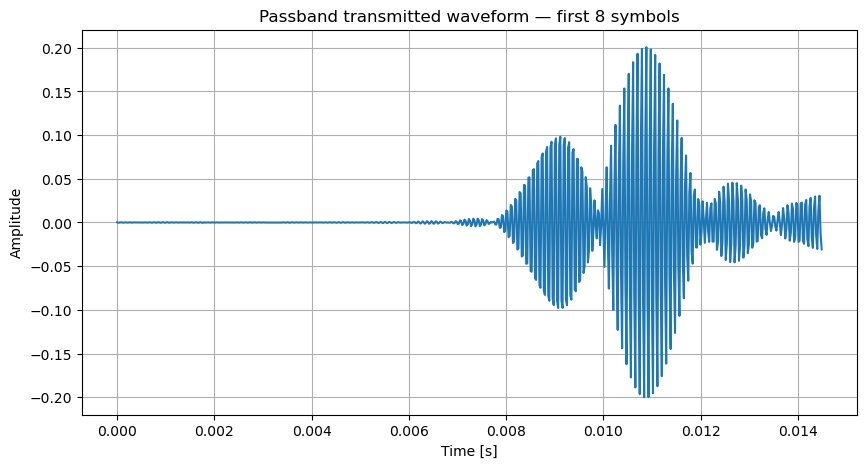

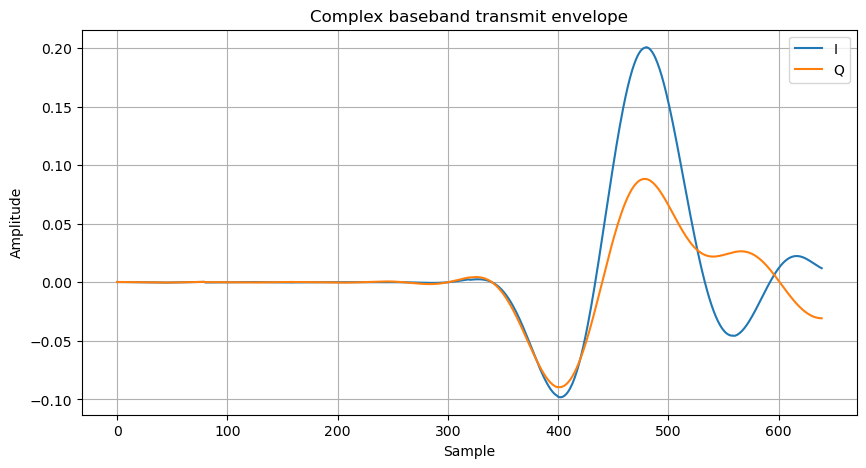

In [6]:
n_show = min(8 * L, len(s))
t_show = np.arange(n_show) / Fs

plt.figure()
plt.plot(t_show, s[:n_show])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Passband transmitted waveform — first 8 symbols")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(np.real(tx_envelope[:n_show]), label="I")
plt.plot(np.imag(tx_envelope[:n_show]), label="Q")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Complex baseband transmit envelope")
plt.legend()
plt.grid(True)
plt.show()


## 5. Channel

`dt_channel.m` does three things:

- clips the real waveform to ±10;
- filters it with the supplied 13th-order IIR channel, approximated in MATLAB by 400 samples of its impulse response;
- adds real AWGN for a nominal SNR of 10 dB.

The numerator and denominator below are copied directly from `dt_getChannelTransferFunction.m`.

In [7]:
B = np.array([
    0.007120601713134337,
   -0.0019222898834068854,
   -0.025844549568524489,
    0.0054572348136679933,
    0.050806725273748889,
   -0.0087782209645750498,
   -0.063641939335278411,
    0.0092490994846975896,
    0.054301646307775862,
   -0.0057386014785145989,
   -0.029362003070503354,
    0.0023980182814972214,
    0.0093308294662545564
])

A = np.array([
    1.0,
   -0.0000000000000049404924595819466,
    2.7445577051566001,
   -0.0000000000000087152507433074788,
    4.4951584808973575,
   -0.0000000000000040523140398818214,
    4.6492043751470664,
   -0.00000000000000055511151231257827,
    3.2299784258838828,
    0.000000000000001915134717478395,
    1.4088842648092788,
    0.0000000000000013183898417423734,
    0.31451868286474216
])

# MATLAB: h=impz(B,A,400)
impulse = np.zeros(400)
impulse[0] = 1.0
h_channel = lfilter(B, A, impulse)

rng_noise = np.random.Generator(np.random.MT19937(0))

def channel(x, snr_db=10.0, rng=None):
    x = np.asarray(x, dtype=float).copy()

    # MATLAB clipping
    pos = x > 10
    neg = x < -10
    if np.any(pos):
        print(f"Warning: positive clips = {np.sum(pos)}")
        x[pos] = 10
    if np.any(neg):
        print(f"Warning: negative clips = {np.sum(neg)}")
        x[neg] = -10

    # MATLAB uses conv(x,h), not filter(x,B,A)
    z = fftconvolve(x, h_channel)

    power_rx = np.mean(np.abs(z)**2)
    snr_linear = 10**(snr_db/10)
    noise_power = power_rx / snr_linear

    if rng is None:
        rng = np.random.default_rng()

    noise = np.sqrt(noise_power) * rng.standard_normal(len(z))
    r = z + noise

    snr_actual = 10*np.log10(np.mean(np.abs(z)**2) / np.mean(noise**2))

    return r, z, noise, snr_actual, power_rx, noise_power

if useIdealChannel:
    r = s.copy()
    z = s.copy()
    noise = np.zeros_like(s)
    snr_actual = np.inf
else:
    r, z, noise, snr_actual, power_rx, noise_power = channel(
        s, SNRdB, rng_noise
    )

print(f"Received signal power = {np.mean(z**2):.6g}")
print(f"Noise power           = {np.mean(noise**2):.6g}")
print(f"Actual SNR             = {snr_actual:.3f} dB")


Received signal power = 0.00653803
Noise power           = 0.000654029
Actual SNR             = 9.998 dB


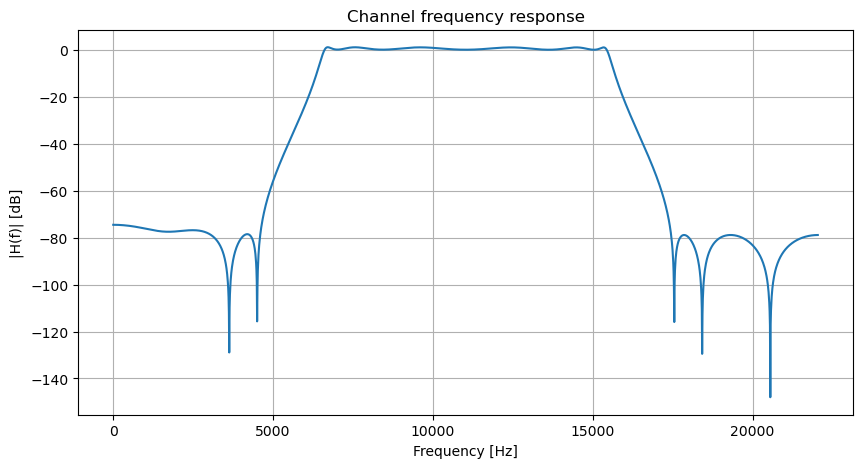

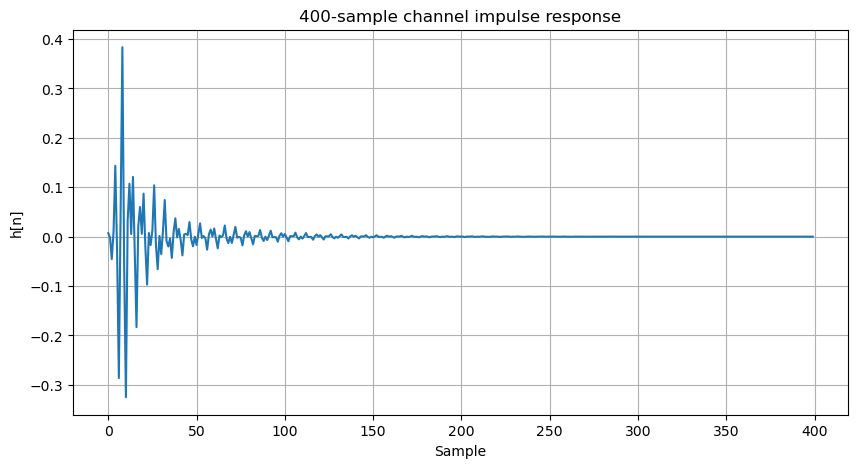

In [8]:
# Channel frequency response
w, H = freqz(B, A, worN=2048, fs=Fs)

plt.figure()
plt.plot(w, 20*np.log10(np.maximum(np.abs(H), 1e-12)))
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H(f)| [dB]")
plt.title("Channel frequency response")
plt.grid(True)
plt.show()

# Channel impulse response used by dt_channel.m
plt.figure()
plt.plot(h_channel)
plt.xlabel("Sample")
plt.ylabel("h[n]")
plt.title("400-sample channel impulse response")
plt.grid(True)
plt.show()


## 6. Receiver

This follows `ak_receiver.m`:

1. Convolve the received real passband signal with the supplied Hilbert FIR.
2. Form the analytic signal.
3. Downconvert by \(e^{-j\omega_c n}\).
4. Apply the matched filter.
5. Skip the accumulated Tx/channel/Rx delay.
6. Sample every `L=80` samples.
7. Apply the fixed phase correction used by the MATLAB script.
8. Make nearest-neighbour QAM decisions.
9. Convert symbol indices back to bits.

The original MATLAB receiver uses a fixed `phaseCorrection = pi/23` when the non-ideal channel is enabled.

In [9]:
def qam_receiver(r, apply_phase_correction=True):
    r = np.asarray(r, dtype=float).ravel()

    # Analytic signal construction exactly following the MATLAB approach.
    yhilbert = fftconvolve(hhilbert, r)

    # MATLAB:
    # yhilbert(1:round((length(hhilbert)-1)/2))=[];
    hilbert_delay = round((len(hhilbert) - 1) / 2)
    yhilbert = yhilbert[hilbert_delay:]

    # Match MATLAB length handling.
    yhilbert = yhilbert[:len(r)]

    ya = r + 1j*yhilbert

    n = np.arange(len(ya))
    ybb = ya * np.exp(-1j * wc * n)

    ybb_filtered = fftconvolve(ybb, hrx)

    # MATLAB delay bookkeeping:
    # Tx RRC delay + channel approximate group delay + Rx RRC delay
    total_delay = tx_filter_delay + 7 + ((len(hrx)-1)//2)

    # MATLAB uses firstSample = delayInSamples and then ys(firstSample:L:end).
    # Python indexing is zero-based, hence the explicit conversion below.
    first_sample = total_delay

    ys = ybb_filtered[first_sample::L][:S]

    if useIdealChannel:
        corrected = ys
    elif apply_phase_correction:
        corrected = ys * np.exp(-1j * phaseCorrection)
    else:
        corrected = ys

    rx_indices = qam_demod(corrected, const)
    rx_bits = indices_to_bits(rx_indices, b)[:Nbits]

    return rx_bits, corrected, ybb, ybb_filtered, total_delay

rx_bits, rx_symbols, ybb, ybb_filtered, total_delay = qam_receiver(r)

print("Receiver delay used:", total_delay, "samples")
print("Recovered symbols:", len(rx_symbols))


Receiver delay used: 807 samples
Recovered symbols: 1000


## 7. BER and symbol-rate results

In [10]:
n_compare = min(len(tx_bits), len(rx_bits))
BER = np.mean(tx_bits[:n_compare] != rx_bits[:n_compare])

baud = Fs / L
rate_bps = baud * b

print(f"BER       = {BER:.6f}")
print(f"Errors    = {np.sum(tx_bits[:n_compare] != rx_bits[:n_compare])}")
print(f"Compared  = {n_compare} bits")
print(f"Baud rate = {baud:.2f} baud")
print(f"Bit rate  = {rate_bps:.2f} bit/s")


BER       = 0.000000
Errors    = 0
Compared  = 5000 bits
Baud rate = 551.25 baud
Bit rate  = 2756.25 bit/s


## 8. Transmitted vs. received symbols

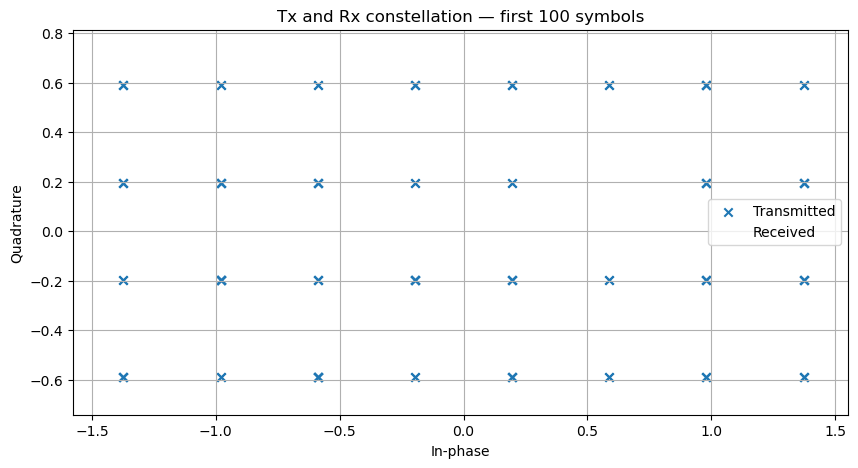

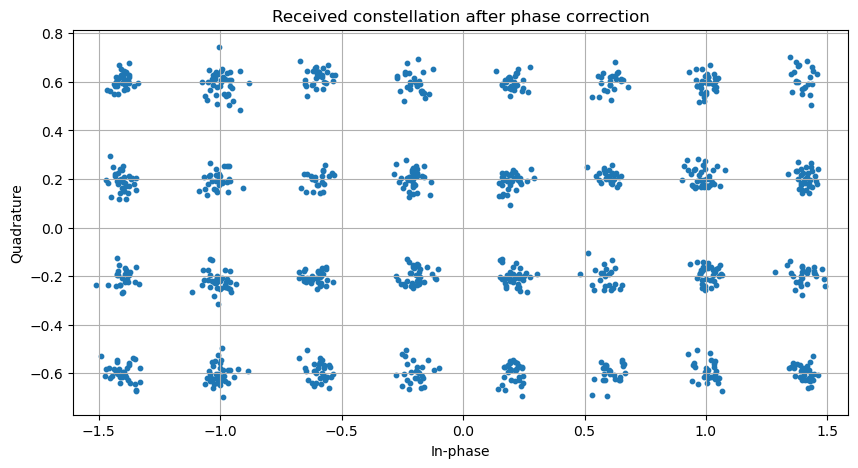

In [11]:
n_sym = min(100, len(rx_symbols))

plt.figure()
plt.scatter(np.real(tx_symbols[:n_sym]), np.imag(tx_symbols[:n_sym]),
            marker="x", label="Transmitted")
plt.scatter(np.real(rx_symbols[:n_sym]), np.imag(rx_symbols[:n_sym]),
            marker="o", facecolors="none", label="Received")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.title("Tx and Rx constellation — first 100 symbols")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

plt.figure()
plt.scatter(rx_symbols.real, rx_symbols.imag, s=10)
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.title("Received constellation after phase correction")
plt.grid(True)
plt.axis("equal")
plt.show()


## 9. Receiver processing diagnostics

These plots correspond to the main processing stages in `ak_receiver.m`: receiver input, downconverted baseband, matched-filter output, and detected symbols.

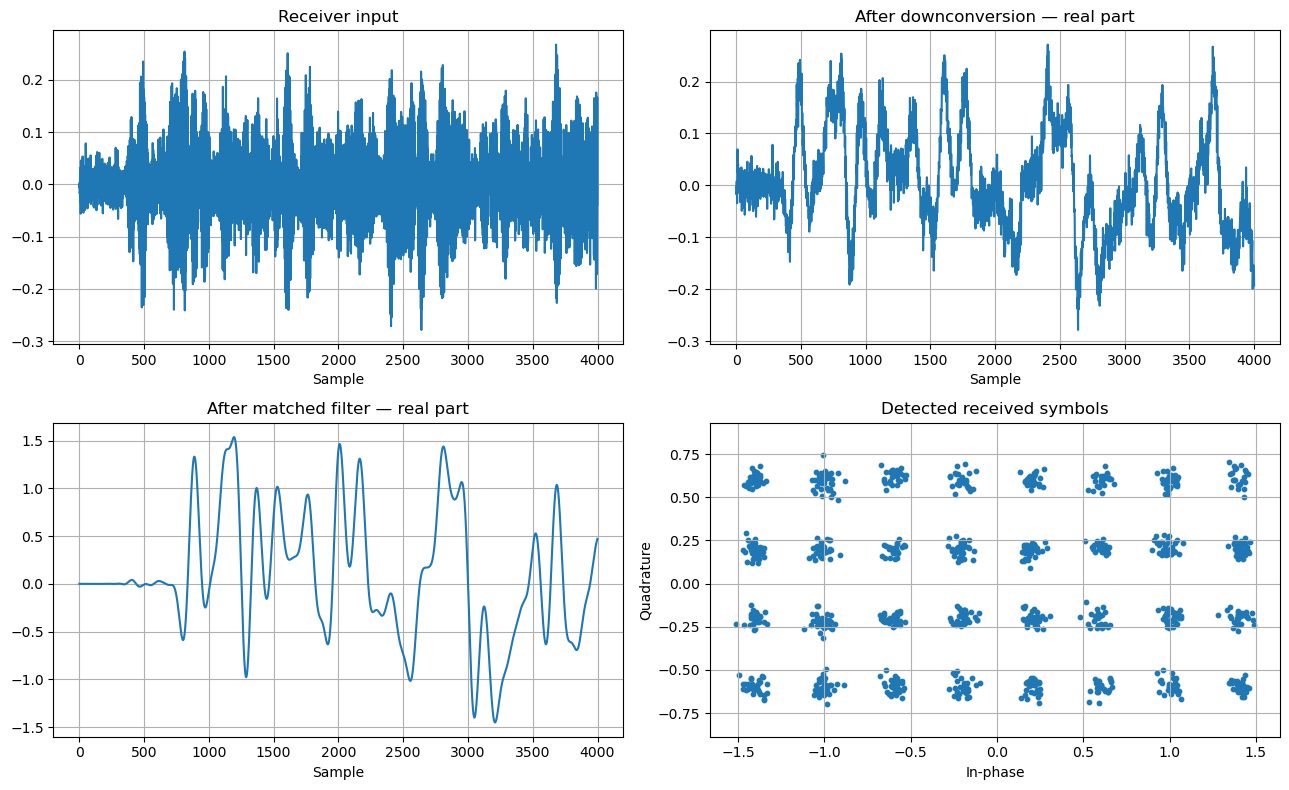

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

n0 = min(4000, len(r))
axes[0, 0].plot(r[:n0])
axes[0, 0].set_title("Receiver input")
axes[0, 0].set_xlabel("Sample")
axes[0, 0].grid(True)

axes[0, 1].plot(np.real(ybb[:n0]))
axes[0, 1].set_title("After downconversion — real part")
axes[0, 1].set_xlabel("Sample")
axes[0, 1].grid(True)

n1 = min(4000, len(ybb_filtered))
axes[1, 0].plot(np.real(ybb_filtered[:n1]))
axes[1, 0].set_title("After matched filter — real part")
axes[1, 0].set_xlabel("Sample")
axes[1, 0].grid(True)

axes[1, 1].scatter(rx_symbols.real, rx_symbols.imag, s=10)
axes[1, 1].set_title("Detected received symbols")
axes[1, 1].set_xlabel("In-phase")
axes[1, 1].set_ylabel("Quadrature")
axes[1, 1].grid(True)
axes[1, 1].axis("equal")

plt.tight_layout()
plt.show()


## 10. Optional ideal-channel comparison

Set `useIdealChannel = True` near the beginning and rerun the notebook to bypass `dt_channel.m`. This corresponds to:

```matlab
if useIdealChannel==1
    r=s;
else
    r=dt_channel(s);
end
```

The non-ideal case is the default and follows the supplied MATLAB code's 10-dB AWGN channel.

In [13]:
# Quick consistency summary
summary = {
    "Sampling frequency (Hz)": Fs,
    "Oversampling L": L,
    "Symbols": S,
    "Bits/symbol": b,
    "Modulation": f"{M}-QAM",
    "Carrier (Hz)": wc * Fs / (2*np.pi),
    "Nominal channel SNR (dB)": SNRdB,
    "Actual channel SNR (dB)": snr_actual,
    "BER": BER,
    "Symbol rate (baud)": baud,
    "Gross bit rate (bit/s)": rate_bps,
}
summary


{'Sampling frequency (Hz)': 44100,
 'Oversampling L': 80,
 'Symbols': 1000,
 'Bits/symbol': 5,
 'Modulation': '32-QAM',
 'Carrier (Hz)': 11025.0,
 'Nominal channel SNR (dB)': 10.0,
 'Actual channel SNR (dB)': 9.998495623334367,
 'BER': 0.0,
 'Symbol rate (baud)': 551.25,
 'Gross bit rate (bit/s)': 2756.25}

## Notes on equivalence with the MATLAB program

- The **channel IIR coefficients** and the **Hilbert FIR coefficients** are copied from the supplied files.
- The channel uses the same 400-sample impulse-response approximation and real AWGN model.
- The transmitter/receiver use the same `Fs=44100`, `L=80`, `M=32`, `S=1000`, and `wc=π/2` settings.
- The original ZIP does **not** include several helper functions called by the main scripts. Consequently, exact numerical identity with the original MATLAB run cannot be guaranteed without those missing helper implementations.
- In particular, the precise `ak_qamSquareConstellation(32)` and `ak_rcosine(...)` definitions may change the constellation scaling/order and therefore the exact BER.
- The MATLAB script resets its legacy random generators with `rand('twister',0)` and `randn('state',0)`. NumPy's MT19937 is used here for reproducibility, but the generated sequences need not be bit-for-bit identical to MATLAB's legacy RNG.
- The notebook intentionally keeps the **signal-processing architecture** of `dt_digital_transmission.m`, rather than replacing it with a high-level communications library abstraction.